## Daily

In [10]:
import pandas as pd, numpy as np

# From the daily data you already built above
# daily has: userid, day, n_replies, n_cross, action

# Users with 10+ active days
user_days_count = daily.groupby("userid")["day"].agg(["count", list]).rename(columns={"count": "n_days", "list": "days"})
user_10plus = user_days_count[user_days_count["n_days"] >= 10].copy()
print(f"Users with 10+ active days: {len(user_10plus):,}")

# Check max gap for each
def max_gap(days_list):
    days_sorted = sorted(days_list)
    if len(days_sorted) < 2:
        return 0
    gaps = [(pd.Timestamp(days_sorted[i+1]) - pd.Timestamp(days_sorted[i])).days 
            for i in range(len(days_sorted)-1)]
    return max(gaps)

user_10plus["max_gap"] = user_10plus["days"].apply(max_gap)
user_10plus["pol"] = user_10plus.index.map(user_pol)

print(f"\nMax gap distribution (10+ day users):")
print(f"  Mean: {user_10plus['max_gap'].mean():.1f}")
print(f"  Median: {user_10plus['max_gap'].median():.0f}")
print(f"  25th: {user_10plus['max_gap'].quantile(0.25):.0f}")
print(f"  75th: {user_10plus['max_gap'].quantile(0.75):.0f}")

for gap_thresh in [14, 21, 30, 45, 60, 90]:
    sub = user_10plus[user_10plus["max_gap"] <= gap_thresh]
    n_lib = (sub["pol"] == 0).sum()
    n_con = (sub["pol"] == 1).sum()
    print(f"\n  Max gap <= {gap_thresh} days: {len(sub):,} users (lib={n_lib:,}, con={n_con:,})")
    if len(sub) > 0:
        print(f"    Days/user: mean={sub['n_days'].mean():.1f}, median={sub['n_days'].median():.0f}")

Users with 10+ active days: 6,065

Max gap distribution (10+ day users):
  Mean: 49.7
  Median: 45
  25th: 32
  75th: 62

  Max gap <= 14 days: 170 users (lib=115, con=55)
    Days/user: mean=22.4, median=16

  Max gap <= 21 days: 492 users (lib=337, con=155)
    Days/user: mean=23.4, median=17

  Max gap <= 30 days: 1,307 users (lib=901, con=406)
    Days/user: mean=21.5, median=17

  Max gap <= 45 days: 3,134 users (lib=2,221, con=913)
    Days/user: mean=18.6, median=15

  Max gap <= 60 days: 4,459 users (lib=3,184, con=1,275)
    Days/user: mean=17.4, median=14

  Max gap <= 90 days: 5,623 users (lib=4,074, con=1,549)
    Days/user: mean=16.6, median=13


In [1]:
import pickle, numpy as np, pandas as pd

with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

shock_date = "2020-07-11"

rows = []
for t in trajs:
    uid = t["user_id"]
    pol = t["political_gen"]
    dates = [s[0] for s in t["trajectory"]]
    actions = [s[4] for s in t["trajectory"]]
    
    pre_idx = [i for i, d in enumerate(dates) if d < shock_date]
    post_idx = [i for i, d in enumerate(dates) if d >= shock_date]
    
    pre_actions = [actions[i] for i in pre_idx]
    post_actions = [actions[i] for i in post_idx]
    
    pre_out = np.mean(pre_actions) if pre_actions else np.nan
    post_out = np.mean(post_actions) if post_actions else np.nan
    
    rows.append({
        "uid": uid, "pol": pol,
        "total": len(dates),
        "pre_n": len(pre_idx), "post_n": len(post_idx),
        "pre_out": pre_out, "post_out": post_out,
        "delta": post_out - pre_out if pre_actions and post_actions else np.nan,
    })

df = pd.DataFrame(rows)

print("=== ALL USERS ===")
print(f"Total: {len(df)}")
print(f"Has both pre & post: {df['delta'].notna().sum()}")

# Filter thresholds: min N actions on EACH side
print("\n=== USERS BY MIN ACTIONS ON EACH SIDE ===")
print(f"{'Min':<6} {'All':>8} {'Lib':>8} {'Con':>8} {'Pre steps (mean)':>18} {'Post steps (mean)':>19}")
print("-" * 70)

for min_n in [3, 5, 7, 10, 15]:
    sub = df[(df["pre_n"] >= min_n) & (df["post_n"] >= min_n)]
    lib = sub[sub["pol"] == 0]
    con = sub[sub["pol"] == 1]
    print(f"{min_n:<6} {len(sub):>8,} {len(lib):>8,} {len(con):>8,} "
          f"{sub['pre_n'].mean():>18.1f} {sub['post_n'].mean():>19.1f}")

# For the best threshold, show behavioral change
print("\n=== BEHAVIORAL CHANGE (min 5 actions each side) ===")
sub = df[(df["pre_n"] >= 5) & (df["post_n"] >= 5)]

for label, s in [("All", sub), ("Liberal", sub[sub["pol"]==0]), ("Conservative", sub[sub["pol"]==1])]:
    if len(s) == 0:
        continue
    inc = (s["delta"] > 0.05).sum()
    dec = (s["delta"] < -0.05).sum()
    stable = len(s) - inc - dec
    print(f"\n{label} ({len(s)} users):")
    print(f"  Pre out-rate:  {s['pre_out'].mean():.3f}")
    print(f"  Post out-rate: {s['post_out'].mean():.3f}")
    print(f"  Delta:         {s['delta'].mean():.3f}")
    print(f"  Increased:     {inc} ({100*inc/len(s):.1f}%)")
    print(f"  Stable:        {stable} ({100*stable/len(s):.1f}%)")
    print(f"  Decreased:     {dec} ({100*dec/len(s):.1f}%)")

# Can we train IRL on pre-shock only?
print("\n=== PRE-SHOCK ONLY IRL FEASIBILITY ===")
for min_n in [10, 15, 20]:
    pre_enough = df[df["pre_n"] >= min_n]
    lib = pre_enough[pre_enough["pol"] == 0]
    con = pre_enough[pre_enough["pol"] == 1]
    print(f"Min {min_n} pre-shock actions: {len(pre_enough):,} users (lib={len(lib):,}, con={len(con):,})")

=== ALL USERS ===
Total: 19398
Has both pre & post: 15437

=== USERS BY MIN ACTIONS ON EACH SIDE ===
Min         All      Lib      Con   Pre steps (mean)   Post steps (mean)
----------------------------------------------------------------------
3        10,387    8,106    2,281                7.0                19.7
5         6,053    4,902    1,151                9.3                23.8
7         3,397    2,837      560               12.2                30.3
10        1,634    1,405      229               16.5                40.2
15          610      521       89               24.2                59.0

=== BEHAVIORAL CHANGE (min 5 actions each side) ===

All (6053 users):
  Pre out-rate:  0.220
  Post out-rate: 0.231
  Delta:         0.011
  Increased:     2548 (42.1%)
  Stable:        1565 (25.9%)
  Decreased:     1940 (32.1%)

Liberal (4902 users):
  Pre out-rate:  0.145
  Post out-rate: 0.172
  Delta:         0.027
  Increased:     2185 (44.6%)
  Stable:        1364 (27.8%)
  Decre

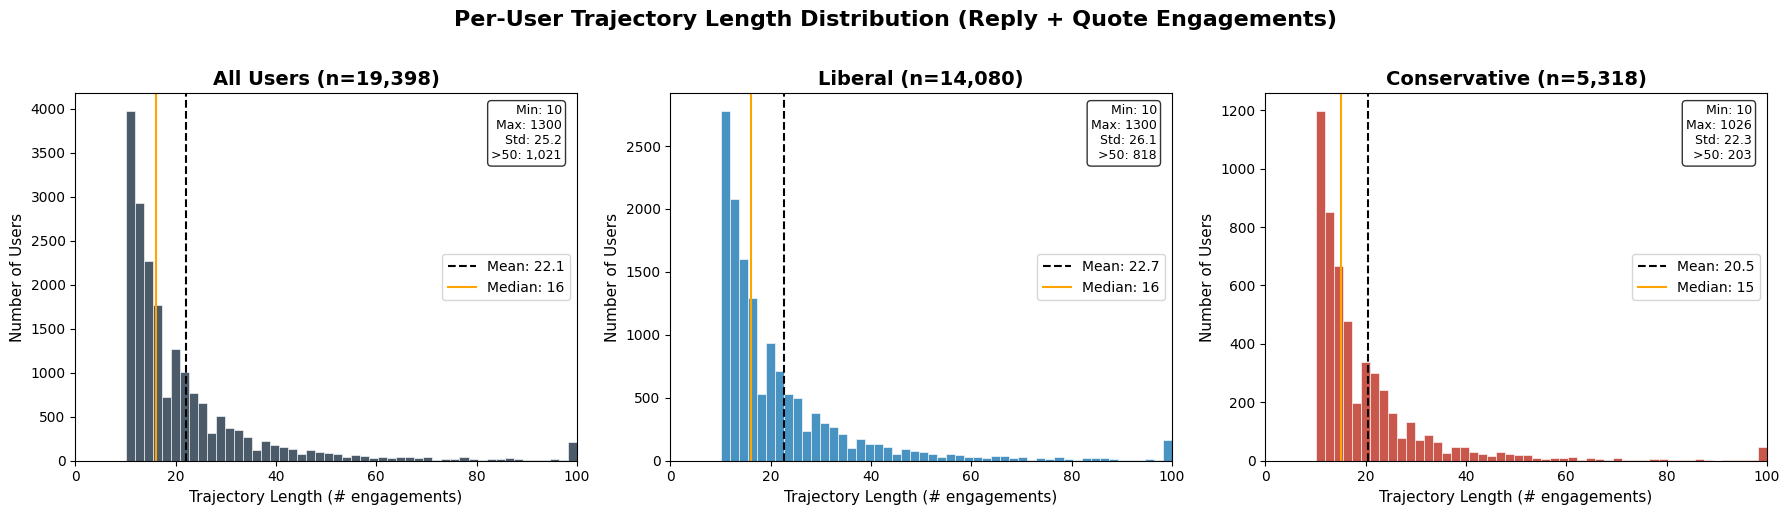

In [1]:
import pickle, numpy as np, matplotlib.pyplot as plt

with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

all_steps = np.array([t["n_steps"] for t in trajs])
lib_steps = np.array([t["n_steps"] for t in trajs if t["political_gen"] == 0])
con_steps = np.array([t["n_steps"] for t in trajs if t["political_gen"] == 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, label, color in [
    (axes[0], all_steps, f"All Users (n={len(all_steps):,})", "#2c3e50"),
    (axes[1], lib_steps, f"Liberal (n={len(lib_steps):,})", "#2980b9"),
    (axes[2], con_steps, f"Conservative (n={len(con_steps):,})", "#c0392b"),
]:
    # Clip for visualization, note in label
    clipped = np.clip(data, 0, 100)
    ax.hist(clipped, bins=50, color=color, edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: {data.mean():.1f}")
    ax.axvline(np.median(data), color="orange", linestyle="-", linewidth=1.5,
               label=f"Median: {np.median(data):.0f}")
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Trajectory Length (# engagements)", fontsize=11)
    ax.set_ylabel("Number of Users", fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 100)
    
    # Add text box with stats
    stats_text = (f"Min: {data.min()}\n"
                  f"Max: {data.max()}\n"
                  f"Std: {data.std():.1f}\n"
                  f">50: {(data>50).sum():,}")
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle("Per-User Trajectory Length Distribution (Reply + Quote Engagements)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("trajectory_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Median thresholds: S1=0.970, S2=0.348, S3=0.143


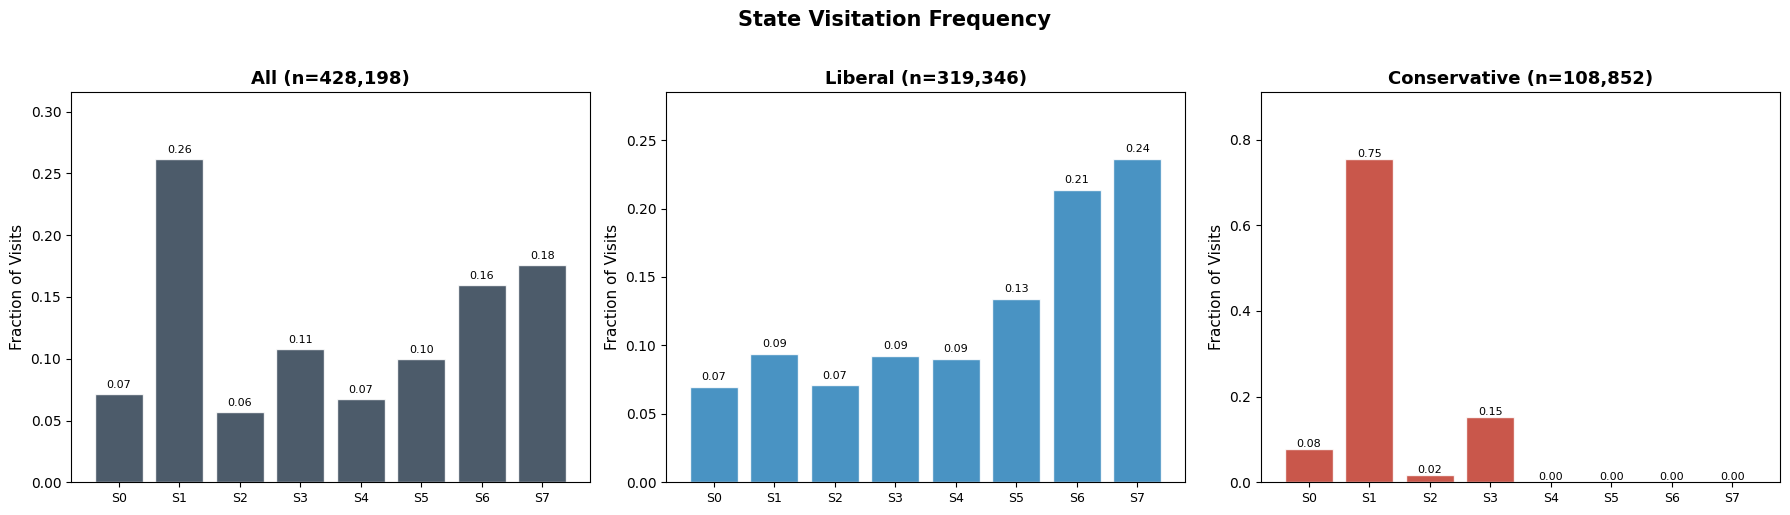

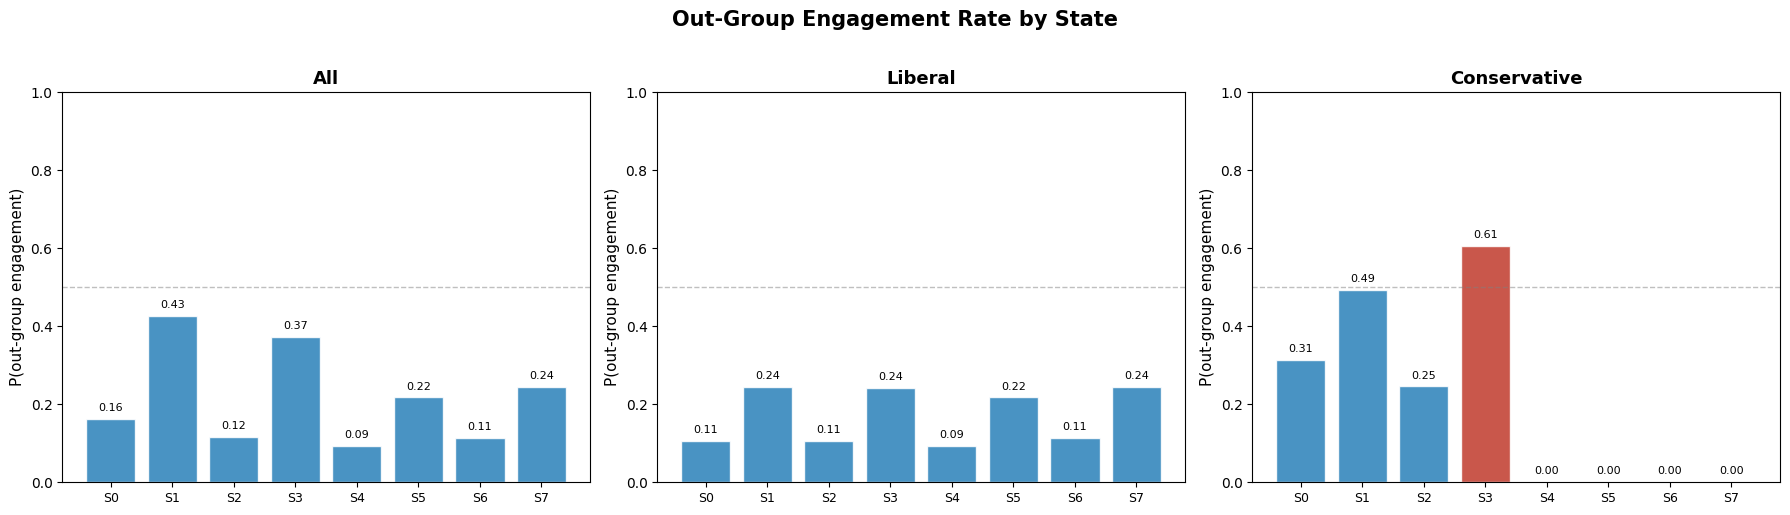

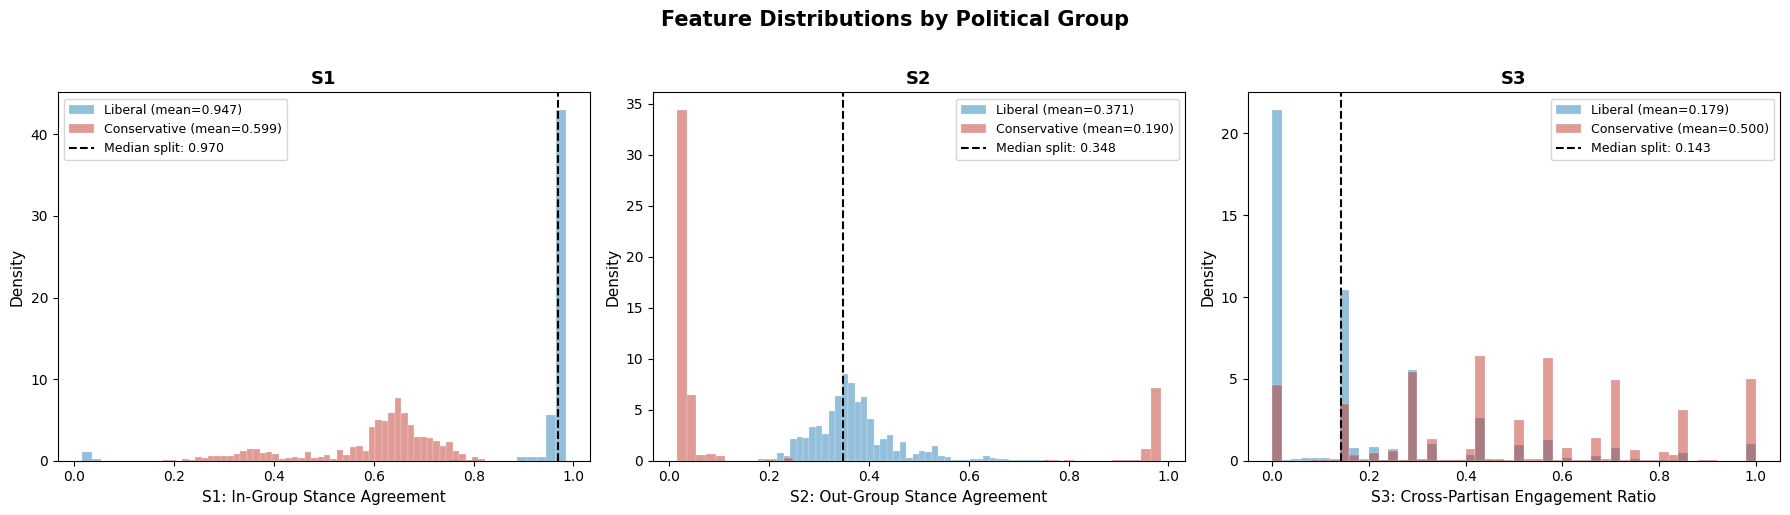

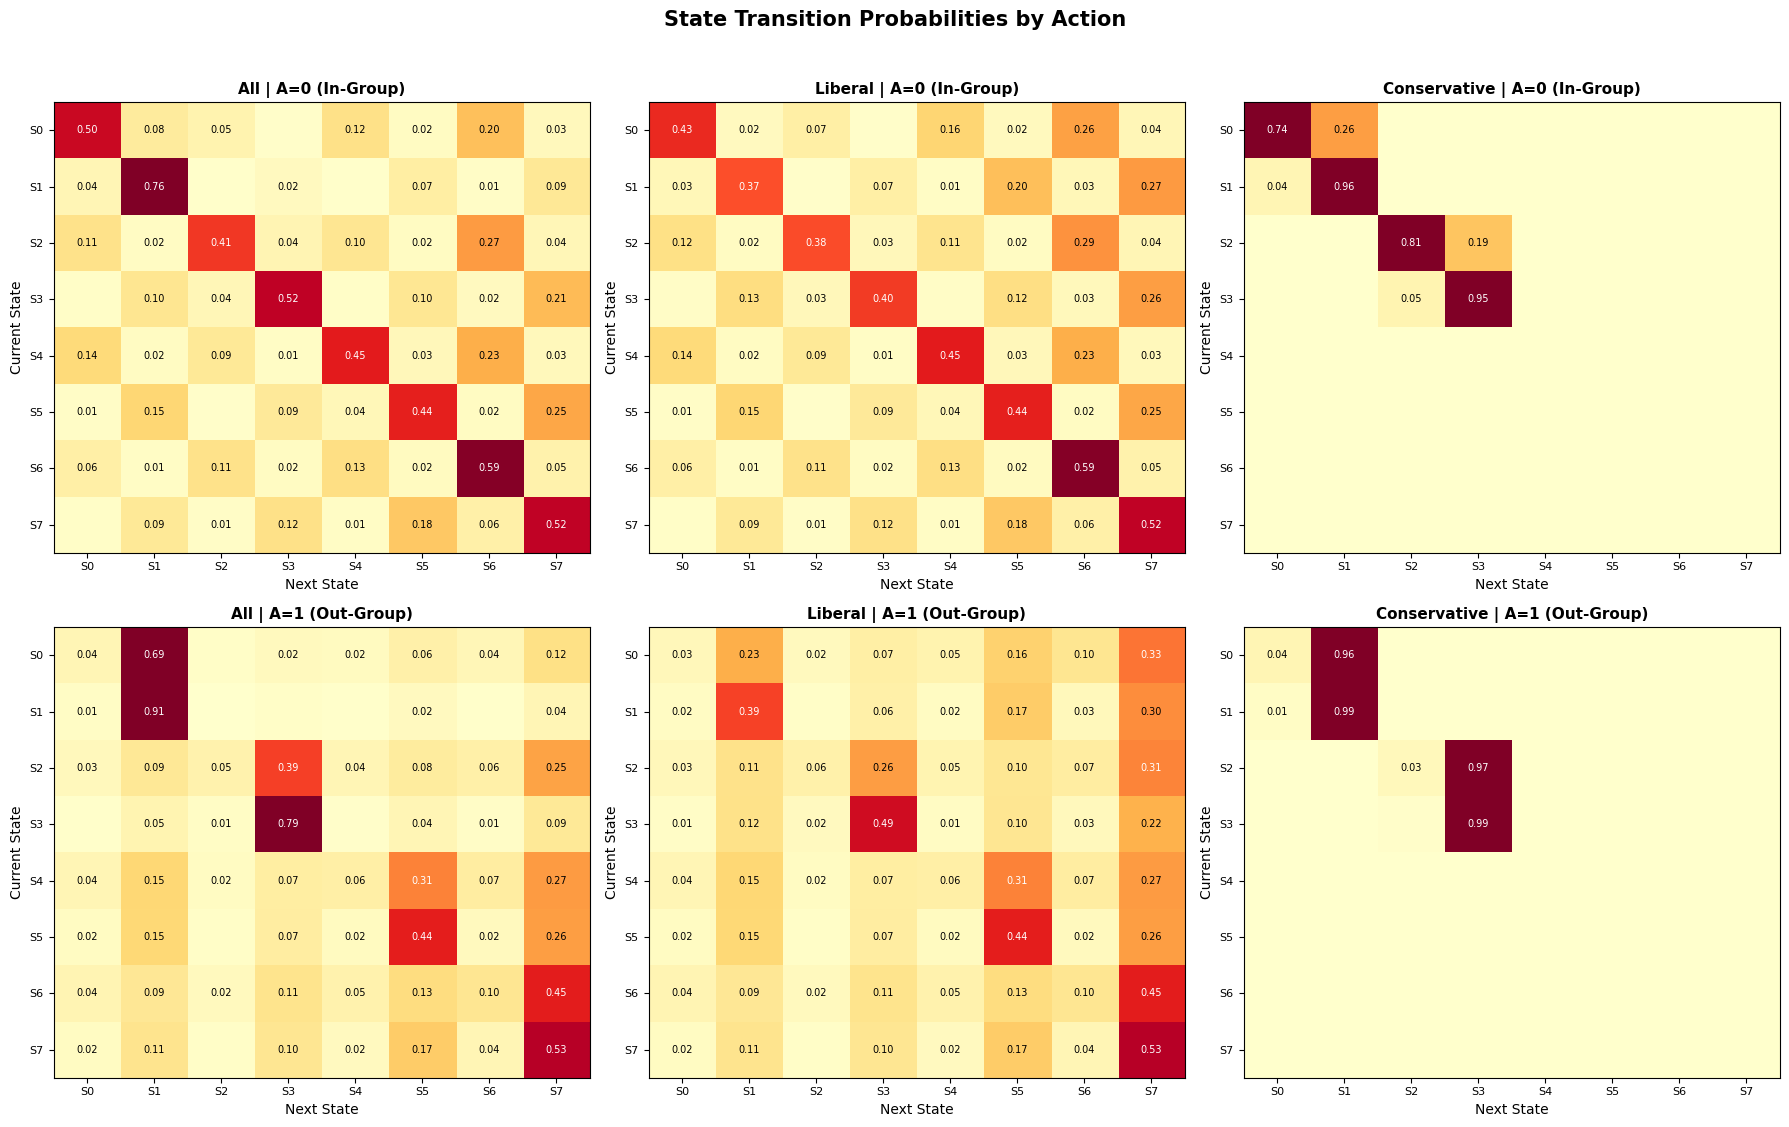


ACTION EFFECT TEST (chi-squared)
Does action affect next-state distribution?

All:
  State      n(A=0)   n(A=1)       chi2      p-value   Sig
  -------- -------- -------- ---------- ------------ -----
  S0        23,381    4,657    28038.0     0.000000   ***
  S1        58,943   45,174     6148.4     0.000000   ***
  S2        21,014    2,780    23794.0     0.000000   ***
  S3        27,674   16,365     4262.9     0.000000   ***
  S4        25,003    2,562    27565.0     0.000000   ***
  S5        31,714    8,855      777.2     0.000000   ***
  S6        59,576    7,691    67267.0     0.000000   ***
  S7        55,471   17,940     2246.4     0.000000   ***
  Passed: 8/8

Liberal:
  State      n(A=0)   n(A=1)       chi2      p-value   Sig
  -------- -------- -------- ---------- ------------ -----
  S0        17,800    2,083    19883.0     0.000000   ***
  S1        19,701    6,480      746.7     0.000000   ***
  S2        19,675    2,337    22012.0     0.000000   ***
  S3        21,523

In [2]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

# Build flat dataframe
rows = []
for t in trajs:
    pol = t["political_gen"]
    for i, (dt, s1, s2, s3, a) in enumerate(t["trajectory"]):
        rows.append({"uid": t["user_id"], "pol": pol, "s1": s1, "s2": s2, "s3": s3, "action": a})
df = pd.DataFrame(rows)

# Discretize same as IRL (median split)
s1_med = df["s1"].median()
s2_med = df["s2"].median()
s3_med = df["s3"].median()
print(f"Median thresholds: S1={s1_med:.3f}, S2={s2_med:.3f}, S3={s3_med:.3f}")

df["s1_bin"] = (df["s1"] >= s1_med).astype(int)
df["s2_bin"] = (df["s2"] >= s2_med).astype(int)
df["s3_bin"] = (df["s3"] >= s3_med).astype(int)
df["state"] = df["s1_bin"] * 4 + df["s2_bin"] * 2 + df["s3_bin"]

state_labels = []
for s1b in ["lowS1", "highS1"]:
    for s2b in ["lowS2", "highS2"]:
        for s3b in ["lowS3", "highS3"]:
            state_labels.append(f"{s1b}\n{s2b}\n{s3b}")

n_states = 8

# ================================================================
# 1. State visitation frequency by group
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, sub, color) in zip(axes, [
    (f"All (n={len(df):,})", df, "#2c3e50"),
    (f"Liberal (n={(df['pol']==0).sum():,})", df[df["pol"]==0], "#2980b9"),
    (f"Conservative (n={(df['pol']==1).sum():,})", df[df["pol"]==1], "#c0392b"),
]):
    counts = sub["state"].value_counts().sort_index()
    freqs = counts / counts.sum()
    bars = ax.bar(range(n_states), [freqs.get(s, 0) for s in range(n_states)],
                  color=color, edgecolor="white", alpha=0.85)
    ax.set_xticks(range(n_states))
    ax.set_xticklabels([f"S{i}" for i in range(n_states)], fontsize=9)
    ax.set_ylabel("Fraction of Visits", fontsize=11)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    for bar, s in zip(bars, range(n_states)):
        val = freqs.get(s, 0)
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.2f}",
                ha="center", fontsize=8)

plt.suptitle("State Visitation Frequency", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mdp_state_visitation.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 2. Action distribution per state, by group
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, sub) in zip(axes, [
    ("All", df),
    ("Liberal", df[df["pol"]==0]),
    ("Conservative", df[df["pol"]==1]),
]):
    out_rates = []
    for s in range(n_states):
        ss = sub[sub["state"] == s]
        out_rates.append(ss["action"].mean() if len(ss) > 0 else 0)

    colors = ["#2980b9" if r < 0.5 else "#c0392b" for r in out_rates]
    bars = ax.bar(range(n_states), out_rates, color=colors, edgecolor="white", alpha=0.85)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xticks(range(n_states))
    ax.set_xticklabels([f"S{i}" for i in range(n_states)], fontsize=9)
    ax.set_ylabel("P(out-group engagement)", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=13, fontweight="bold")
    for bar, r in zip(bars, out_rates):
        ax.text(bar.get_x() + bar.get_width()/2, r + 0.02, f"{r:.2f}",
                ha="center", fontsize=8)

plt.suptitle("Out-Group Engagement Rate by State", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mdp_action_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 3. Feature distributions by group (S1, S2, S3)
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (feat, fname, med) in zip(axes, [
    ("s1", "S1: In-Group Stance Agreement", s1_med),
    ("s2", "S2: Out-Group Stance Agreement", s2_med),
    ("s3", "S3: Cross-Partisan Engagement Ratio", s3_med),
]):
    lib_vals = df[df["pol"]==0][feat]
    con_vals = df[df["pol"]==1][feat]
    ax.hist(lib_vals, bins=50, alpha=0.5, color="#2980b9", label=f"Liberal (mean={lib_vals.mean():.3f})",
            density=True, edgecolor="white", linewidth=0.3)
    ax.hist(con_vals, bins=50, alpha=0.5, color="#c0392b", label=f"Conservative (mean={con_vals.mean():.3f})",
            density=True, edgecolor="white", linewidth=0.3)
    ax.axvline(med, color="black", linestyle="--", linewidth=1.5, label=f"Median split: {med:.3f}")
    ax.set_xlabel(fname, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(fname.split(":")[0], fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Feature Distributions by Political Group", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mdp_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 4. Transition matrix heatmaps (state-to-state, by action)
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for col, (label, sub) in enumerate([
    ("All", df),
    ("Liberal", df[df["pol"]==0]),
    ("Conservative", df[df["pol"]==1]),
]):
    for row, (a_label, a_val) in enumerate([("A=0 (In-Group)", 0), ("A=1 (Out-Group)", 1)]):
        ax = axes[row, col]
        # Build transitions
        tp = np.zeros((n_states, n_states))
        sub_a = sub[sub["action"] == a_val]
        for uid, grp in sub_a.groupby("uid"):
            states = grp["state"].values
            for i in range(len(states) - 1):
                tp[states[i], states[i+1]] += 1

        # Normalize rows
        row_sums = tp.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        tp_norm = tp / row_sums

        im = ax.imshow(tp_norm, cmap="YlOrRd", vmin=0, vmax=0.6, aspect="auto")
        ax.set_xticks(range(n_states))
        ax.set_yticks(range(n_states))
        ax.set_xticklabels([f"S{i}" for i in range(n_states)], fontsize=8)
        ax.set_yticklabels([f"S{i}" for i in range(n_states)], fontsize=8)
        ax.set_xlabel("Next State", fontsize=10)
        ax.set_ylabel("Current State", fontsize=10)
        ax.set_title(f"{label} | {a_label}", fontsize=11, fontweight="bold")

        # Annotate cells
        for i in range(n_states):
            for j in range(n_states):
                val = tp_norm[i, j]
                if val > 0.01:
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                            color="white" if val > 0.3 else "black")

plt.suptitle("State Transition Probabilities by Action", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mdp_transitions.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 5. Action effect test (chi-squared)
# ================================================================
from scipy.stats import chi2_contingency

print("\n" + "=" * 60)
print("ACTION EFFECT TEST (chi-squared)")
print("Does action affect next-state distribution?")
print("=" * 60)

for label, sub in [("All", df), ("Liberal", df[df["pol"]==0]), ("Conservative", df[df["pol"]==1])]:
    print(f"\n{label}:")
    print(f"  {'State':<8} {'n(A=0)':>8} {'n(A=1)':>8} {'chi2':>10} {'p-value':>12} {'Sig':>5}")
    print(f"  {'-'*8} {'-'*8} {'-'*8} {'-'*10} {'-'*12} {'-'*5}")

    n_pass = 0
    for s in range(n_states):
        # For each starting state, build contingency: action x next_state
        sub_s = sub[sub["state"] == s]
        # Need next state
        next_states = []
        for uid, grp in sub_s.groupby("uid"):
            idx = grp.index
            for i in idx:
                if i + 1 in sub.index and sub.loc[i+1, "uid"] == uid:
                    next_states.append((sub.loc[i, "action"], sub.loc[i+1, "state"]))

        if len(next_states) < 10:
            print(f"  S{s:<6} {'--':>8} {'--':>8} {'--':>10} {'too few':>12}")
            continue

        ns_df = pd.DataFrame(next_states, columns=["action", "next_state"])
        ct = pd.crosstab(ns_df["action"], ns_df["next_state"])
        n_a0 = (ns_df["action"] == 0).sum()
        n_a1 = (ns_df["action"] == 1).sum()

        if ct.shape[0] < 2 or ct.shape[1] < 2:
            print(f"  S{s:<6} {n_a0:>8} {n_a1:>8} {'--':>10} {'degenerate':>12}")
            continue

        chi2, p, dof, expected = chi2_contingency(ct)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        if p < 0.05:
            n_pass += 1
        print(f"  S{s:<6} {n_a0:>8,} {n_a1:>8,} {chi2:>10.1f} {p:>12.6f} {sig:>5}")

    print(f"  Passed: {n_pass}/8")

# ================================================================
# 6. State label reference
# ================================================================
print("\n" + "=" * 60)
print("STATE LABEL REFERENCE")
print("=" * 60)
for s in range(n_states):
    s1b = "high" if s // 4 == 1 else "low"
    s2b = "high" if (s % 4) // 2 == 1 else "low"
    s3b = "high" if s % 2 == 1 else "low"
    print(f"  State {s}: S1={s1b:<5} S2={s2b:<5} S3={s3b:<5}")

In [3]:
import pickle
import pandas as pd

with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

rows = []
for t in trajs:
    for step in t["trajectory"]:
        rows.append({"pol": t["political_gen"], "action": step[4]})
df = pd.DataFrame(rows)

print("ACTION DISTRIBUTION")
print("=" * 50)
for label, pol in [("All", None), ("Liberal", 0), ("Conservative", 1)]:
    sub = df if pol is None else df[df["pol"] == pol]
    n = len(sub)
    a0 = (sub["action"] == 0).sum()
    a1 = (sub["action"] == 1).sum()
    print(f"\n{label} ({n:,} steps):")
    print(f"  A=0 (in-group):  {a0:>8,}  ({100*a0/n:.1f}%)")
    print(f"  A=1 (out-group): {a1:>8,}  ({100*a1/n:.1f}%)")
    print(f"  Majority baseline accuracy: {max(a0,a1)/n:.3f}")

ACTION DISTRIBUTION

All (428,198 steps):
  A=0 (in-group):   317,224  (74.1%)
  A=1 (out-group):  110,974  (25.9%)
  Majority baseline accuracy: 0.741

Liberal (319,346 steps):
  A=0 (in-group):   262,052  (82.1%)
  A=1 (out-group):   57,294  (17.9%)
  Majority baseline accuracy: 0.821

Conservative (108,852 steps):
  A=0 (in-group):    55,172  (50.7%)
  A=1 (out-group):   53,680  (49.3%)
  Majority baseline accuracy: 0.507


SHOCK ANALYSIS: Trump Wears Mask (2020-07-11)
Min 5 engagements on each side

--- BEHAVIORAL CHANGE SUMMARY ---

Group                N   Pre Rate  Post Rate    Delta      Inc   Stable      Dec
---------------------------------------------------------------------------
All              6,053      0.220      0.231   +0.011  2548 (42.1%) 1565 (25.9%) 1940 (32.1%)
Liberal          4,902      0.145      0.172   +0.027  2185 (44.6%) 1364 (27.8%) 1353 (27.6%)
Conservative     1,151      0.540      0.483   -0.057   363 (31.5%) 201 (17.5%)  587 (51.0%)

--- STATISTICAL SIGNIFICANCE OF SHIFT ---

All:
  Wilcoxon signed-rank: stat=6837877.0, p=0.000000 ***
  Paired t-test:       stat=4.589, p=0.000005 ***
Liberal:
  Wilcoxon signed-rank: stat=3793615.0, p=0.000000 ***
  Paired t-test:       stat=11.135, p=0.000000 ***
Conservative:
  Wilcoxon signed-rank: stat=225702.0, p=0.000000 ***
  Paired t-test:       stat=-8.088, p=0.000000 ***


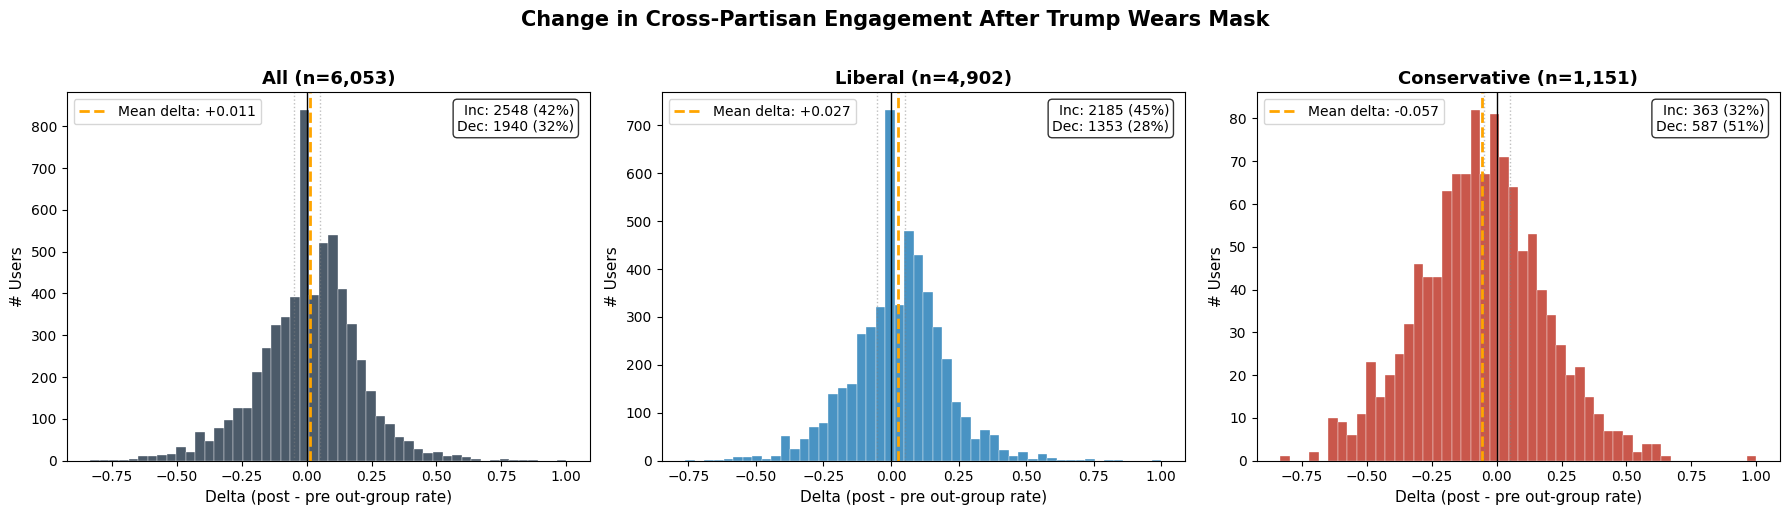

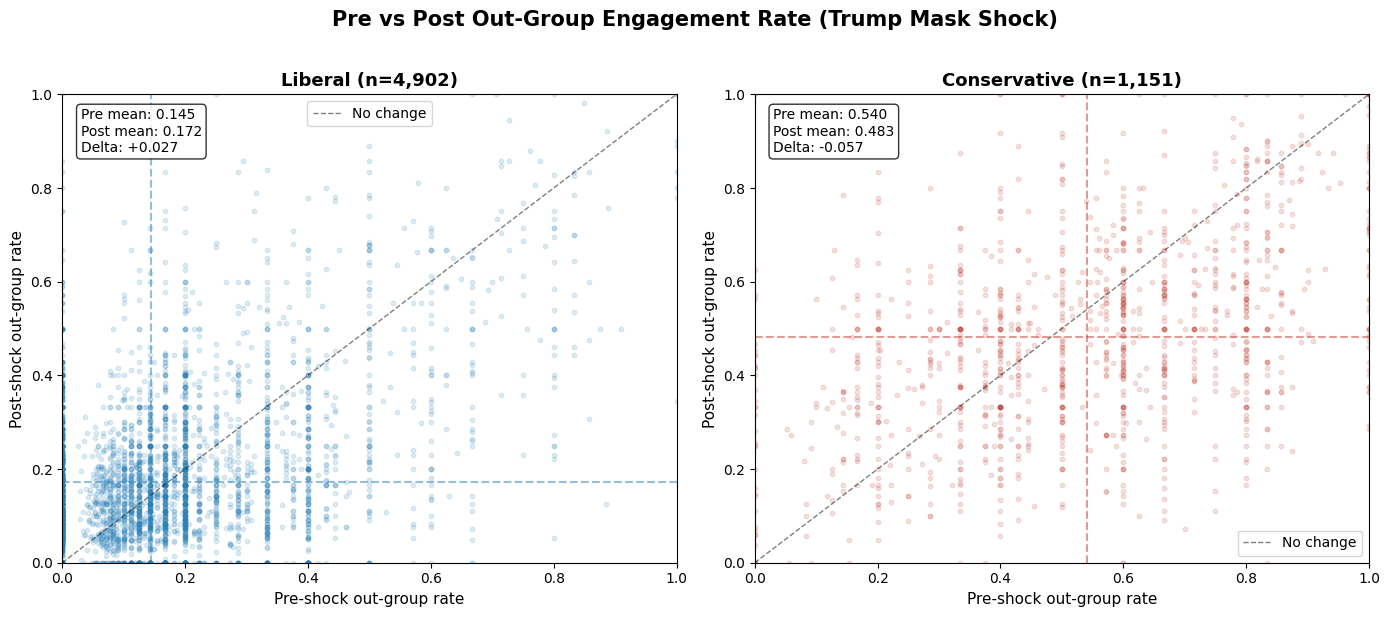

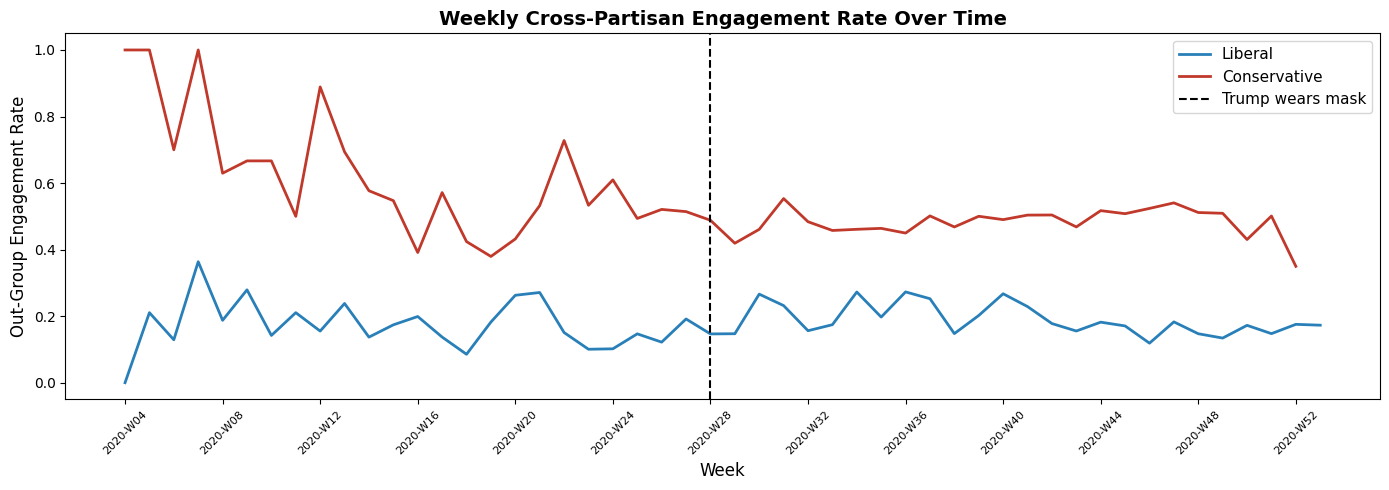


--- WHAT IS DELTA? ---

Delta = post_out_rate - pre_out_rate

For each user:
  pre_out_rate  = fraction of pre-shock engagements targeting out-group
  post_out_rate = fraction of post-shock engagements targeting out-group
  delta         = change in cross-partisan engagement after the shock

Example:
  User A: 10 pre-shock engagements, 3 were out-group -> pre_rate = 0.30
          15 post-shock engagements, 6 were out-group -> post_rate = 0.40
          delta = +0.10 (increased cross-partisan engagement)

Classification:
  delta > +0.05  -> "Increased" (more cross-partisan after shock)
  delta < -0.05  -> "Decreased" (less cross-partisan after shock)
  otherwise      -> "Stable"



In [6]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr

with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

shock_date = "2020-07-11"
min_steps = 5

# ================================================================
# 1. Build per-user pre/post metrics
# ================================================================
rows = []
for t in trajs:
    pre = [s for s in t["trajectory"] if s[0] < shock_date]
    post = [s for s in t["trajectory"] if s[0] >= shock_date]
    if len(pre) < min_steps or len(post) < min_steps:
        continue
    
    pre_actions = [s[4] for s in pre]
    post_actions = [s[4] for s in post]
    pre_rate = np.mean(pre_actions)
    post_rate = np.mean(post_actions)
    
    rows.append({
        "uid": t["user_id"],
        "pol": t["political_gen"],
        "pol_label": "Liberal" if t["political_gen"] == 0 else "Conservative",
        "pre_n": len(pre),
        "post_n": len(post),
        "pre_out_rate": pre_rate,
        "post_out_rate": post_rate,
        "delta": post_rate - pre_rate,
    })

df = pd.DataFrame(rows)

# Classify behavioral change
df["change"] = "Stable"
df.loc[df["delta"] > 0.05, "change"] = "Increased"
df.loc[df["delta"] < -0.05, "change"] = "Decreased"

print("=" * 70)
print(f"SHOCK ANALYSIS: Trump Wears Mask ({shock_date})")
print(f"Min {min_steps} engagements on each side")
print("=" * 70)

# ================================================================
# 2. Summary by group
# ================================================================
print("\n--- BEHAVIORAL CHANGE SUMMARY ---\n")
print(f"{'Group':<15} {'N':>6} {'Pre Rate':>10} {'Post Rate':>10} {'Delta':>8} {'Inc':>8} {'Stable':>8} {'Dec':>8}")
print("-" * 75)

for label in ["All", "Liberal", "Conservative"]:
    sub = df if label == "All" else df[df["pol_label"] == label]
    inc = (sub["change"] == "Increased").sum()
    stable = (sub["change"] == "Stable").sum()
    dec = (sub["change"] == "Decreased").sum()
    print(f"{label:<15} {len(sub):>6,} {sub['pre_out_rate'].mean():>10.3f} {sub['post_out_rate'].mean():>10.3f} "
          f"{sub['delta'].mean():>+8.3f} {inc:>5} ({100*inc/len(sub):>4.1f}%) "
          f"{stable:>3} ({100*stable/len(sub):>4.1f}%) "
          f"{dec:>4} ({100*dec/len(sub):>4.1f}%)")

# ================================================================
# 3. Statistical tests: is the shift significant?
# ================================================================
print("\n--- STATISTICAL SIGNIFICANCE OF SHIFT ---\n")
from scipy.stats import wilcoxon, ttest_rel

for label in ["All", "Liberal", "Conservative"]:
    sub = df if label == "All" else df[df["pol_label"] == label]
    stat_w, p_w = wilcoxon(sub["post_out_rate"], sub["pre_out_rate"])
    stat_t, p_t = ttest_rel(sub["post_out_rate"], sub["pre_out_rate"])
    print(f"{label}:")
    print(f"  Wilcoxon signed-rank: stat={stat_w:.1f}, p={p_w:.6f} {'***' if p_w<0.001 else '**' if p_w<0.01 else '*' if p_w<0.05 else ''}")
    print(f"  Paired t-test:       stat={stat_t:.3f}, p={p_t:.6f} {'***' if p_t<0.001 else '**' if p_t<0.01 else '*' if p_t<0.05 else ''}")

# ================================================================
# 4. Delta distribution by group
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, color) in zip(axes, [("All", "#2c3e50"), ("Liberal", "#2980b9"), ("Conservative", "#c0392b")]):
    sub = df if label == "All" else df[df["pol_label"] == label]
    
    ax.hist(sub["delta"], bins=50, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="black", linestyle="-", linewidth=1)
    ax.axvline(sub["delta"].mean(), color="orange", linestyle="--", linewidth=2,
               label=f"Mean delta: {sub['delta'].mean():+.3f}")
    ax.axvline(0.05, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.axvline(-0.05, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    
    inc = (sub["change"] == "Increased").sum()
    dec = (sub["change"] == "Decreased").sum()
    ax.set_title(f"{label} (n={len(sub):,})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Delta (post - pre out-group rate)", fontsize=11)
    ax.set_ylabel("# Users", fontsize=11)
    ax.legend(fontsize=10)
    
    ax.text(0.97, 0.97, f"Inc: {inc} ({100*inc/len(sub):.0f}%)\nDec: {dec} ({100*dec/len(sub):.0f}%)",
            transform=ax.transAxes, fontsize=10, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Change in Cross-Partisan Engagement After Trump Wears Mask",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("shock_delta_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 5. Pre vs Post scatter
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, pol, color) in zip(axes, [("Liberal", 0, "#2980b9"), ("Conservative", 1, "#c0392b")]):
    sub = df[df["pol"] == pol]
    ax.scatter(sub["pre_out_rate"], sub["post_out_rate"], alpha=0.15, s=10, color=color)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="No change")
    ax.set_xlabel("Pre-shock out-group rate", fontsize=11)
    ax.set_ylabel("Post-shock out-group rate", fontsize=11)
    ax.set_title(f"{label} (n={len(sub):,})", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    
    # Add means
    ax.axvline(sub["pre_out_rate"].mean(), color=color, linestyle="--", alpha=0.5)
    ax.axhline(sub["post_out_rate"].mean(), color=color, linestyle="--", alpha=0.5)
    ax.text(0.03, 0.97, f"Pre mean: {sub['pre_out_rate'].mean():.3f}\nPost mean: {sub['post_out_rate'].mean():.3f}\nDelta: {sub['delta'].mean():+.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Pre vs Post Out-Group Engagement Rate (Trump Mask Shock)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("shock_pre_post_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# 6. Time series around shock
# ================================================================
all_rows = []
for t in trajs:
    for s in t["trajectory"]:
        all_rows.append({"date": s[0], "pol": t["political_gen"], "action": s[4]})
ts = pd.DataFrame(all_rows)
ts["date"] = pd.to_datetime(ts["date"])
ts["week"] = ts["date"].dt.isocalendar().week.astype(int)
ts["year_week"] = ts["date"].dt.isocalendar().year.astype(str) + "-W" + ts["date"].dt.isocalendar().week.astype(str).str.zfill(2)

weekly = ts.groupby(["year_week", "pol"]).agg(
    out_rate=("action", "mean"),
    n=("action", "count"),
).reset_index()
weekly = weekly.sort_values("year_week")

fig, ax = plt.subplots(figsize=(14, 5))

for pol, label, color in [(0, "Liberal", "#2980b9"), (1, "Conservative", "#c0392b")]:
    sub = weekly[weekly["pol"] == pol]
    ax.plot(range(len(sub)), sub["out_rate"].values, color=color, label=label, linewidth=2)

# Mark shock
shock_week = "2020-W28"
lib_weeks = weekly[weekly["pol"] == 0]["year_week"].tolist()
if shock_week in lib_weeks:
    shock_idx = lib_weeks.index(shock_week)
    ax.axvline(shock_idx, color="black", linestyle="--", linewidth=1.5, label="Trump wears mask")

ax.set_ylabel("Out-Group Engagement Rate", fontsize=12)
ax.set_xlabel("Week", fontsize=12)
ax.set_title("Weekly Cross-Partisan Engagement Rate Over Time", fontsize=14, fontweight="bold")

# Set x ticks every 4 weeks
tick_pos = range(0, len(lib_weeks), 4)
tick_labels = [lib_weeks[i] for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("shock_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- WHAT IS DELTA? ---")
print("""
Delta = post_out_rate - pre_out_rate

For each user:
  pre_out_rate  = fraction of pre-shock engagements targeting out-group
  post_out_rate = fraction of post-shock engagements targeting out-group
  delta         = change in cross-partisan engagement after the shock

Example:
  User A: 10 pre-shock engagements, 3 were out-group -> pre_rate = 0.30
          15 post-shock engagements, 6 were out-group -> post_rate = 0.40
          delta = +0.10 (increased cross-partisan engagement)

Classification:
  delta > +0.05  -> "Increased" (more cross-partisan after shock)
  delta < -0.05  -> "Decreased" (less cross-partisan after shock)
  otherwise      -> "Stable"
""")

In [7]:
import pandas as pd, numpy as np, pickle
from scipy.stats import spearmanr, mannwhitneyu

# Load per-user IRL rewards (from full trajectory)
rewards_df = pd.read_parquet("/data/dchu/covid_masking_irl_action/deep_irl_per_user.parquet")
print(f"Users with IRL rewards: {len(rewards_df):,}")

# Load trajectories for shock delta
with open("/data/dchu/covid_masking_irl_action/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

shock_date = "2020-07-11"
min_steps = 5

shock_rows = []
for t in trajs:
    pre = [s for s in t["trajectory"] if s[0] < shock_date]
    post = [s for s in t["trajectory"] if s[0] >= shock_date]
    if len(pre) < min_steps or len(post) < min_steps:
        continue
    pre_rate = np.mean([s[4] for s in pre])
    post_rate = np.mean([s[4] for s in post])
    shock_rows.append({
        "user_id": t["user_id"],
        "pol": t["political_gen"],
        "pre_out_rate": pre_rate,
        "post_out_rate": post_rate,
        "delta": post_rate - pre_rate,
    })

shock_df = pd.DataFrame(shock_rows)
print(f"Users with shock data (min {min_steps} each side): {len(shock_df):,}")

# Merge
df = rewards_df.merge(shock_df, on="user_id", how="inner")
print(f"Users with both IRL rewards and shock data: {len(df):,}")
print(f"  Liberal: {(df['pol']==0).sum():,}")
print(f"  Conservative: {(df['pol']==1).sum():,}")

# Classify
df["change"] = "Stable"
df.loc[df["delta"] > 0.05, "change"] = "Increased"
df.loc[df["delta"] < -0.05, "change"] = "Decreased"

n_states = 8

# ================================================================
# 1. Spearman correlation: reward vs delta
# ================================================================
print("\n" + "=" * 70)
print("REWARD-BEHAVIOR CORRELATION")
print("Do per-user rewards predict who changes behavior?")
print("=" * 70)

for label, pol in [("Liberal", 0), ("Conservative", 1)]:
    sub = df[df["pol"] == pol]
    print(f"\n{label} ({len(sub):,} users):")
    print(f"  {'State':<12} {'Spearman r':>12} {'p-value':>12} {'Sig':>6}")
    print(f"  {'-'*12} {'-'*12} {'-'*12} {'-'*6}")
    for s in range(n_states):
        col = f"reward_s{s}"
        r, p = spearmanr(sub[col], sub["delta"])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {col:<12} {r:>12.4f} {p:>12.6f} {sig:>6}")

# ================================================================
# 2. Mann-Whitney: increasers vs decreasers
# ================================================================
print("\n" + "=" * 70)
print("REWARD DIFFERENCES: INCREASERS vs DECREASERS")
print("=" * 70)

for label, pol in [("Liberal", 0), ("Conservative", 1)]:
    inc = df[(df["pol"] == pol) & (df["change"] == "Increased")]
    dec = df[(df["pol"] == pol) & (df["change"] == "Decreased")]
    print(f"\n{label}: {len(inc):,} increasers vs {len(dec):,} decreasers")
    print(f"  {'State':<12} {'Inc mean':>10} {'Dec mean':>10} {'Diff':>10} {'MW p':>12} {'Sig':>5}")
    print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*12} {'-'*5}")
    for s in range(n_states):
        col = f"reward_s{s}"
        inc_vals = inc[col].values
        dec_vals = dec[col].values
        stat, p = mannwhitneyu(inc_vals, dec_vals, alternative="two-sided")
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        diff = inc_vals.mean() - dec_vals.mean()
        print(f"  {col:<12} {inc_vals.mean():>10.4f} {dec_vals.mean():>10.4f} {diff:>+10.4f} {p:>12.6f} {sig:>5}")

# ================================================================
# 3. State label reference
# ================================================================
print("\n" + "=" * 70)
print("STATE REFERENCE")
print("=" * 70)
for s in range(n_states):
    s1 = "high" if s // 4 == 1 else "low"
    s2 = "high" if (s % 4) // 2 == 1 else "low"
    s3 = "high" if s % 2 == 1 else "low"
    print(f"  State {s}: S1={s1:<5} S2={s2:<5} S3={s3:<5}")

Users with IRL rewards: 19,398
Users with shock data (min 5 each side): 6,053
Users with both IRL rewards and shock data: 6,053
  Liberal: 4,902
  Conservative: 1,151

REWARD-BEHAVIOR CORRELATION
Do per-user rewards predict who changes behavior?

Liberal (4,902 users):
  State          Spearman r      p-value    Sig
  ------------ ------------ ------------ ------
  reward_s0          0.1271     0.000000    ***
  reward_s1          0.1227     0.000000    ***
  reward_s2          0.1169     0.000000    ***
  reward_s3         -0.0097     0.498764       
  reward_s4         -0.1629     0.000000    ***
  reward_s5          0.1661     0.000000    ***
  reward_s6          0.1925     0.000000    ***
  reward_s7         -0.2132     0.000000    ***

Conservative (1,151 users):
  State          Spearman r      p-value    Sig
  ------------ ------------ ------------ ------
  reward_s0          0.1415     0.000001    ***
  reward_s1          0.1514     0.000000    ***
  reward_s2          0.1488  

Loaded from: /data/dchu/covid_masking_irl_action_v2/trajectories.pkl


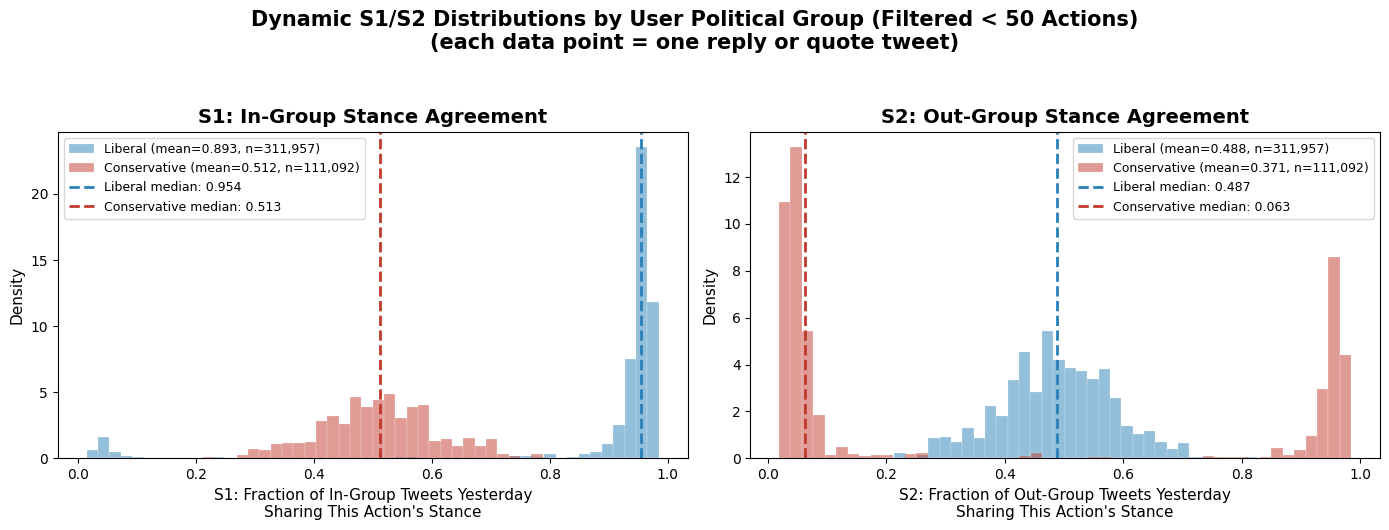

In [2]:
import pickle, numpy as np, matplotlib.pyplot as plt

# Explicitly point to the v2 trajectories
path = "/data/dchu/covid_masking_irl_action_v2/trajectories.pkl"

try:
    with open(path, "rb") as f:
        trajs = pickle.load(f)
    print(f"Loaded from: {path}")
except FileNotFoundError:
    print(f"Error: Could not find {path}. Ensure the v2 build script is finished!")
    exit()

lib_s1, lib_s2 = [], []
con_s1, con_s2 = [], []

for t in trajs:
    # Filter OUT users with 50+ actions (keep only those with < 50)
    if len(t["trajectory"]) >= 50:
        continue

    pol = t["political_gen"]
    for step in t["trajectory"]:
        s1, s2 = step[1], step[2]
        if pol == 0:
            lib_s1.append(s1)
            lib_s2.append(s2)
        else:
            con_s1.append(s1)
            con_s2.append(s2)

lib_s1 = np.array(lib_s1)
lib_s2 = np.array(lib_s2)
con_s1 = np.array(con_s1)
con_s2 = np.array(con_s2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# S1
ax = axes[0]
ax.hist(lib_s1, bins=50, alpha=0.5, color="#2980b9", density=True,
        edgecolor="white", linewidth=0.3,
        label=f"Liberal (mean={lib_s1.mean():.3f}, n={len(lib_s1):,})")
ax.hist(con_s1, bins=50, alpha=0.5, color="#c0392b", density=True,
        edgecolor="white", linewidth=0.3,
        label=f"Conservative (mean={con_s1.mean():.3f}, n={len(con_s1):,})")
ax.axvline(np.median(lib_s1), color="#2980b9", linestyle="--", linewidth=2,
           label=f"Liberal median: {np.median(lib_s1):.3f}")
ax.axvline(np.median(con_s1), color="#c0392b", linestyle="--", linewidth=2,
           label=f"Conservative median: {np.median(con_s1):.3f}")
ax.set_xlabel("S1: Fraction of In-Group Tweets Yesterday\nSharing This Action's Stance", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("S1: In-Group Stance Agreement", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)

# S2
ax = axes[1]
ax.hist(lib_s2, bins=50, alpha=0.5, color="#2980b9", density=True,
        edgecolor="white", linewidth=0.3,
        label=f"Liberal (mean={lib_s2.mean():.3f}, n={len(lib_s2):,})")
ax.hist(con_s2, bins=50, alpha=0.5, color="#c0392b", density=True,
        edgecolor="white", linewidth=0.3,
        label=f"Conservative (mean={con_s2.mean():.3f}, n={len(con_s2):,})")
ax.axvline(np.median(lib_s2), color="#2980b9", linestyle="--", linewidth=2,
           label=f"Liberal median: {np.median(lib_s2):.3f}")
ax.axvline(np.median(con_s2), color="#c0392b", linestyle="--", linewidth=2,
           label=f"Conservative median: {np.median(con_s2):.3f}")
ax.set_xlabel("S2: Fraction of Out-Group Tweets Yesterday\nSharing This Action's Stance", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("S2: Out-Group Stance Agreement", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Dynamic S1/S2 Distributions by User Political Group (Filtered < 50 Actions)\n(each data point = one reply or quote tweet)",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("dynamic_s1_s2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Total users: 1,183
Liberal: 945
Conservative: 238
Steps/user: mean=86.4, median=68

Group             N both   Pre mean    Pre med  Post mean   Post med
-----------------------------------------------------------------
All                1,073       17.0         14       68.2         55
Liberal              862       17.1         14       67.5         54
Conservative         211       16.3         11       71.2         56

Min steps         All  Liberal      Con
----------------------------------------
Min 3           1,004      814      190
Min 5             943      771      172
Min 7             874      722      152
Min 10            731      615      116
Min 15            489      417       72
Min 20            292      250       42


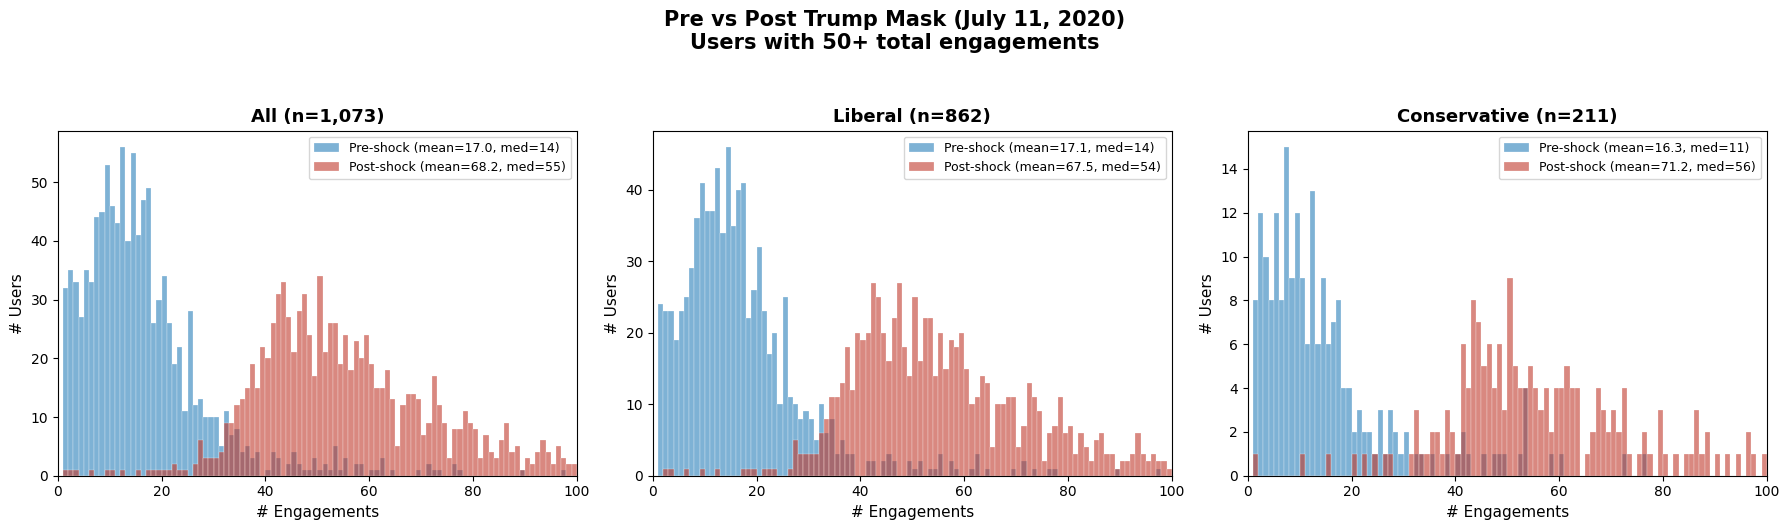

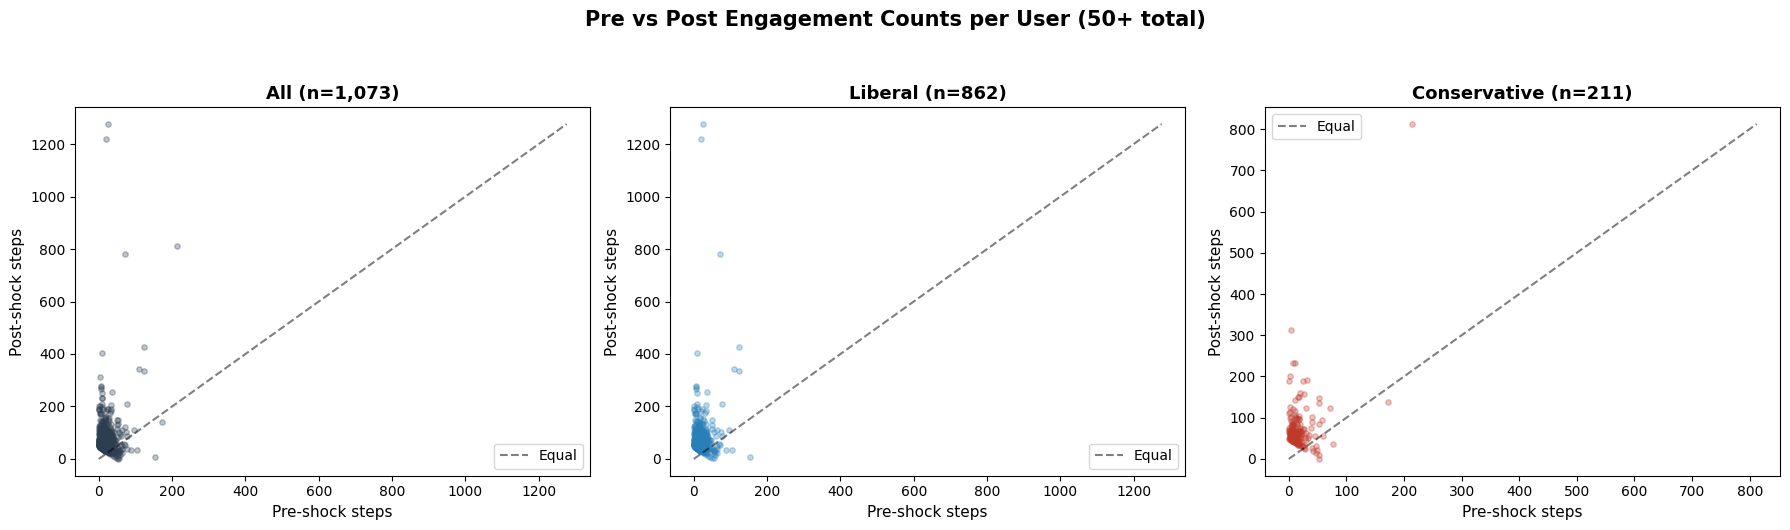

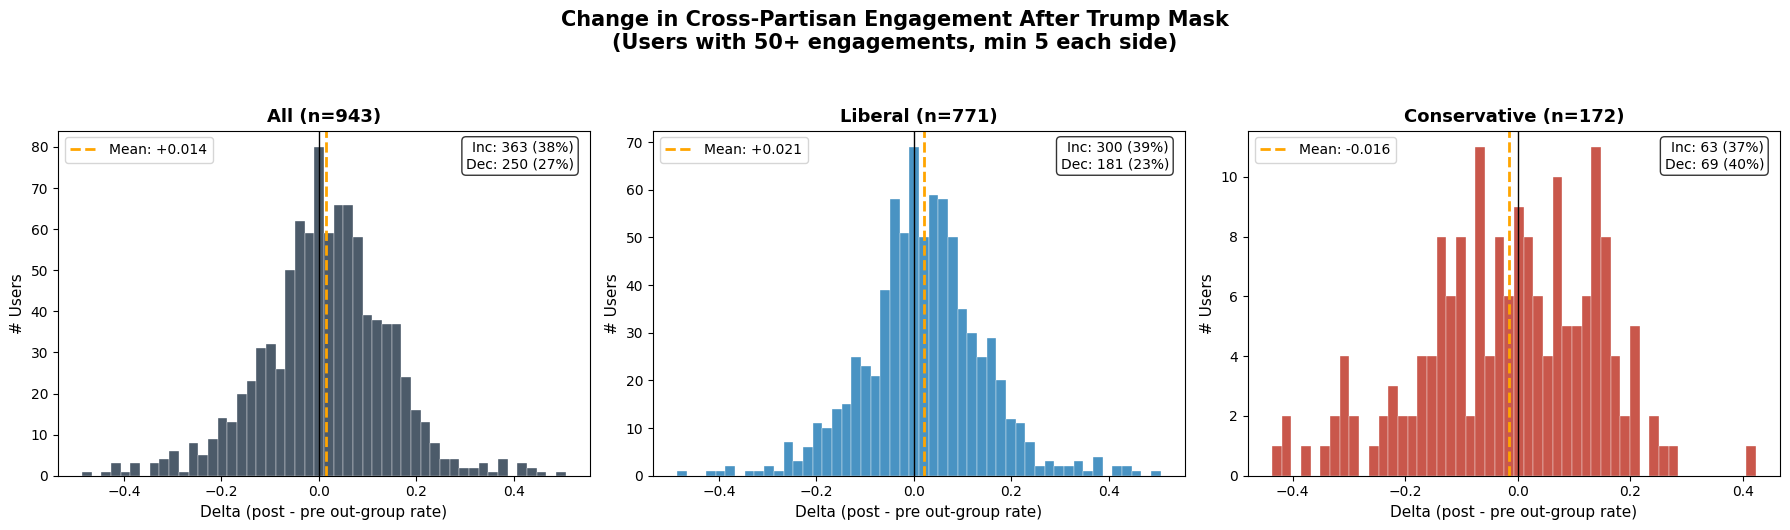

In [2]:
import pickle, numpy as np, matplotlib.pyplot as plt

with open("/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/subset_50/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

shock_date = "2020-07-11"

# Collect pre/post counts
data = {"All": {"pre": [], "post": []}, "Liberal": {"pre": [], "post": []}, "Conservative": {"pre": [], "post": []}}

for t in trajs:
    pre = [s for s in t["trajectory"] if s[0] < shock_date]
    post = [s for s in t["trajectory"] if s[0] >= shock_date]
    if not pre or not post:
        continue
    pol = "Liberal" if t["political_gen"] == 0 else "Conservative"
    data["All"]["pre"].append(len(pre))
    data["All"]["post"].append(len(post))
    data[pol]["pre"].append(len(pre))
    data[pol]["post"].append(len(post))

# Print stats
print(f"Total users: {len(trajs):,}")
print(f"Liberal: {sum(1 for t in trajs if t['political_gen']==0):,}")
print(f"Conservative: {sum(1 for t in trajs if t['political_gen']==1):,}")
print(f"Steps/user: mean={np.mean([t['n_steps'] for t in trajs]):.1f}, median={np.median([t['n_steps'] for t in trajs]):.0f}")

print(f"\n{'Group':<15} {'N both':>8} {'Pre mean':>10} {'Pre med':>10} {'Post mean':>10} {'Post med':>10}")
print("-" * 65)

for label in ["All", "Liberal", "Conservative"]:
    pre = data[label]["pre"]
    post = data[label]["post"]
    if pre:
        print(f"{label:<15} {len(pre):>8,} {np.mean(pre):>10.1f} {np.median(pre):>10.0f} "
              f"{np.mean(post):>10.1f} {np.median(post):>10.0f}")

print(f"\n{'Min steps':<12} {'All':>8} {'Liberal':>8} {'Con':>8}")
print("-" * 40)
for min_n in [3, 5, 7, 10, 15, 20]:
    counts = {}
    for label in ["All", "Liberal", "Conservative"]:
        counts[label] = sum(1 for p, q in zip(data[label]["pre"], data[label]["post"]) if p >= min_n and q >= min_n)
    print(f"Min {min_n:<8} {counts['All']:>8,} {counts['Liberal']:>8,} {counts['Conservative']:>8,}")

# ================================================================
# Plot 1: Pre vs Post trajectory length distribution
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, ["All", "Liberal", "Conservative"]):
    pre = np.array(data[label]["pre"])
    post = np.array(data[label]["post"])
    if len(pre) == 0:
        continue
    
    bins = range(1, max(np.max(pre), np.max(post)) + 2)
    ax.hist(pre, bins=bins, alpha=0.6, color="#2980b9", edgecolor="white", linewidth=0.3,
            label=f"Pre-shock (mean={pre.mean():.1f}, med={np.median(pre):.0f})")
    ax.hist(post, bins=bins, alpha=0.6, color="#c0392b", edgecolor="white", linewidth=0.3,
            label=f"Post-shock (mean={post.mean():.1f}, med={np.median(post):.0f})")
    ax.set_xlabel("# Engagements", fontsize=11)
    ax.set_ylabel("# Users", fontsize=11)
    ax.set_title(f"{label} (n={len(pre):,})", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)

plt.suptitle("Pre vs Post Trump Mask (July 11, 2020)\nUsers with 50+ total engagements",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("subset50_pre_post_shock_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# Plot 2: Pre vs Post scatter
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, color) in zip(axes, [("All", "#2c3e50"), ("Liberal", "#2980b9"), ("Conservative", "#c0392b")]):
    pre = np.array(data[label]["pre"])
    post = np.array(data[label]["post"])
    if len(pre) == 0:
        continue
    
    ax.scatter(pre, post, alpha=0.3, s=15, color=color)
    mx = max(pre.max(), post.max())
    ax.plot([0, mx], [0, mx], "k--", alpha=0.5, label="Equal")
    ax.set_xlabel("Pre-shock steps", fontsize=11)
    ax.set_ylabel("Post-shock steps", fontsize=11)
    ax.set_title(f"{label} (n={len(pre):,})", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)

plt.suptitle("Pre vs Post Engagement Counts per User (50+ total)",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("subset50_pre_post_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ================================================================
# Plot 3: Behavioral change (delta distribution)
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, color) in zip(axes, [("All", "#2c3e50"), ("Liberal", "#2980b9"), ("Conservative", "#c0392b")]):
    deltas = []
    for t in trajs:
        pol_label = "Liberal" if t["political_gen"] == 0 else "Conservative"
        if label != "All" and pol_label != label:
            continue
        pre = [s for s in t["trajectory"] if s[0] < shock_date]
        post = [s for s in t["trajectory"] if s[0] >= shock_date]
        if len(pre) < 5 or len(post) < 5:
            continue
        pre_rate = np.mean([s[-1] for s in pre])
        post_rate = np.mean([s[-1] for s in post])
        deltas.append(post_rate - pre_rate)
    
    deltas = np.array(deltas)
    if len(deltas) == 0:
        continue
    
    ax.hist(deltas, bins=50, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="black", linestyle="-", linewidth=1)
    ax.axvline(deltas.mean(), color="orange", linestyle="--", linewidth=2,
               label=f"Mean: {deltas.mean():+.3f}")
    
    inc = (deltas > 0.05).sum()
    dec = (deltas < -0.05).sum()
    ax.set_title(f"{label} (n={len(deltas):,})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Delta (post - pre out-group rate)", fontsize=11)
    ax.set_ylabel("# Users", fontsize=11)
    ax.legend(fontsize=10)
    ax.text(0.97, 0.97, f"Inc: {inc} ({100*inc/len(deltas):.0f}%)\nDec: {dec} ({100*dec/len(deltas):.0f}%)",
            transform=ax.transAxes, fontsize=10, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Change in Cross-Partisan Engagement After Trump Mask\n(Users with 50+ engagements, min 5 each side)",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("subset50_shock_delta.png", dpi=150, bbox_inches="tight")
plt.show()

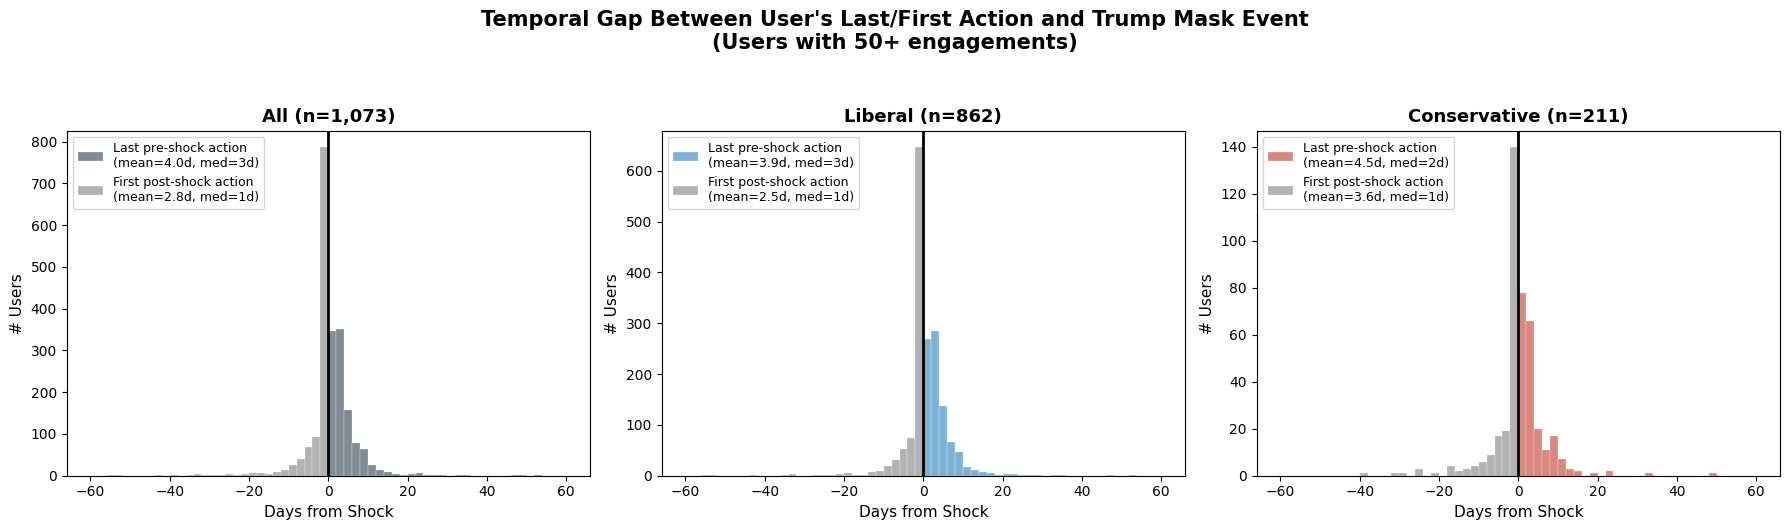

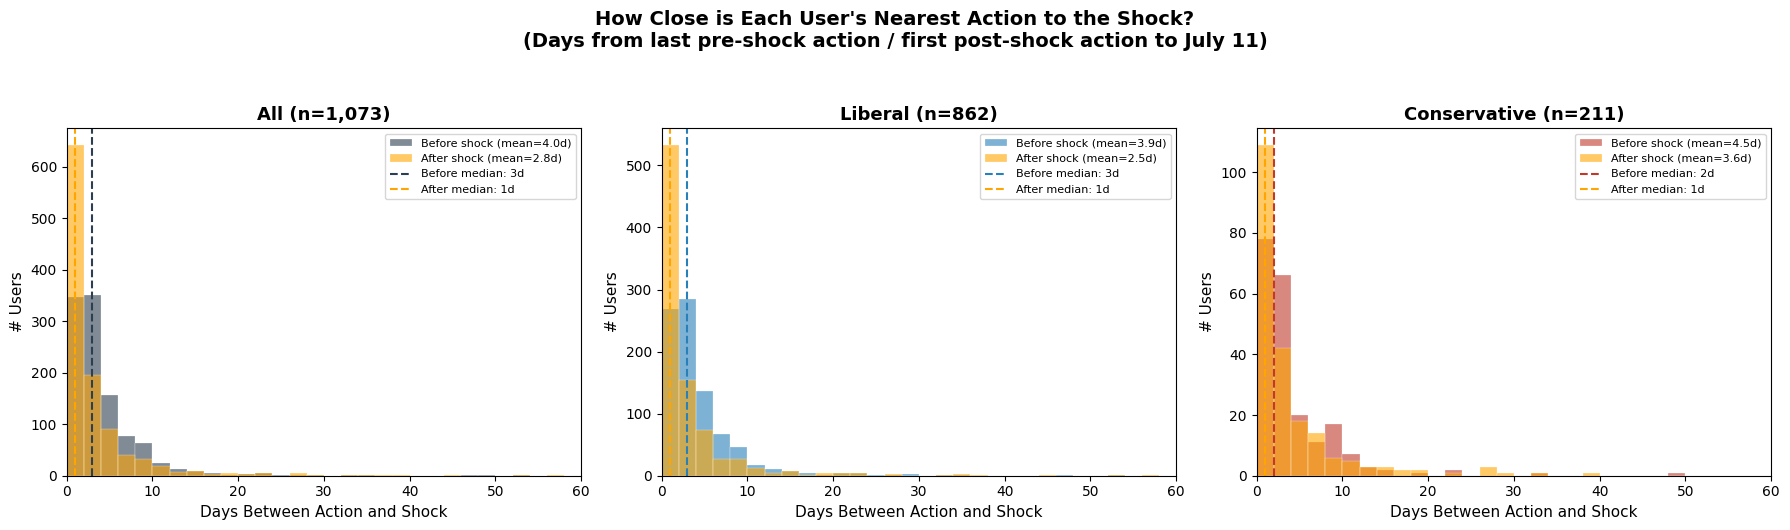

In [3]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt

with open("/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/subset_50/trajectories.pkl", "rb") as f:
    trajs = pickle.load(f)

shock_date = pd.Timestamp("2020-07-11")

rows = []
for t in trajs:
    pol = t["political_gen"]
    pre_dates = [pd.Timestamp(s[0]) for s in t["trajectory"] if s[0] < "2020-07-11"]
    post_dates = [pd.Timestamp(s[0]) for s in t["trajectory"] if s[0] >= "2020-07-11"]
    if not pre_dates or not post_dates:
        continue
    last_pre = max(pre_dates)
    first_post = min(post_dates)
    rows.append({
        "pol": pol,
        "days_before": (shock_date - last_pre).days,
        "days_after": (first_post - shock_date).days,
    })

df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, pol, color) in zip(axes, [
    ("All", None, "#2c3e50"),
    ("Liberal", 0, "#2980b9"),
    ("Conservative", 1, "#c0392b"),
]):
    sub = df if pol is None else df[df["pol"] == pol]
    
    bins = range(0, 62, 2)
    ax.hist(sub["days_before"], bins=bins, alpha=0.6, color=color, edgecolor="white", linewidth=0.3,
            label=f"Last pre-shock action\n(mean={sub['days_before'].mean():.1f}d, med={sub['days_before'].median():.0f}d)")
    ax.hist(-sub["days_after"], bins=[-x for x in reversed(bins)], alpha=0.6, color="gray", edgecolor="white", linewidth=0.3,
            label=f"First post-shock action\n(mean={sub['days_after'].mean():.1f}d, med={sub['days_after'].median():.0f}d)")
    
    ax.axvline(0, color="black", linestyle="-", linewidth=2)
    ax.set_xlabel("Days from Shock", fontsize=11)
    ax.set_ylabel("# Users", fontsize=11)
    ax.set_title(f"{label} (n={len(sub):,})", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")

plt.suptitle("Temporal Gap Between User's Last/First Action and Trump Mask Event\n(Users with 50+ engagements)",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("subset50_shock_temporal_gap.png", dpi=150, bbox_inches="tight")
plt.show()

# Alternative: cleaner paired histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, pol, color) in zip(axes, [
    ("All", None, "#2c3e50"),
    ("Liberal", 0, "#2980b9"),
    ("Conservative", 1, "#c0392b"),
]):
    sub = df if pol is None else df[df["pol"] == pol]
    
    bins = range(0, 62, 2)
    
    ax.hist(sub["days_before"], bins=bins, alpha=0.6, color=color, edgecolor="white", linewidth=0.3,
            label=f"Before shock (mean={sub['days_before'].mean():.1f}d)")
    ax.hist(sub["days_after"], bins=bins, alpha=0.6, color="orange", edgecolor="white", linewidth=0.3,
            label=f"After shock (mean={sub['days_after'].mean():.1f}d)")
    
    ax.axvline(sub["days_before"].median(), color=color, linestyle="--", linewidth=1.5,
               label=f"Before median: {sub['days_before'].median():.0f}d")
    ax.axvline(sub["days_after"].median(), color="orange", linestyle="--", linewidth=1.5,
               label=f"After median: {sub['days_after'].median():.0f}d")
    
    ax.set_xlabel("Days Between Action and Shock", fontsize=11)
    ax.set_ylabel("# Users", fontsize=11)
    ax.set_title(f"{label} (n={len(sub):,})", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 60)

plt.suptitle("How Close is Each User's Nearest Action to the Shock?\n(Days from last pre-shock action / first post-shock action to July 11)",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("subset50_shock_temporal_gap_clean.png", dpi=150, bbox_inches="tight")
plt.show()